In [ ]:
import zipfile
import os

# Define the paths for train and test zip files
train_zip_path = "/content/train.zip"
test_zip_path = "/content/test.zip"

# Define extraction paths
train_extract_path = "/content/train_dataset"
test_extract_path = "/content/test_dataset"

# Function to extract zip files
def extract_zip(zip_path, extract_to):
    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to)
            print(f" Extracted: {zip_path} to {extract_to}")
        except zipfile.BadZipFile:
            print(f" Error: {zip_path} is corrupted or not a valid ZIP file.")
    else:
        print(f" Error: {zip_path} not found!")

# Extract both train and test datasets
extract_zip(train_zip_path, train_extract_path)
extract_zip(test_zip_path, test_extract_path)


 Extracted: /content/train.zip to /content/train_dataset
 Extracted: /content/test.zip to /content/test_dataset


In [ ]:
!pip install opencv-python matplotlib numpy tensorflow keras

In [ ]:
#Import Necessary Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
# Define Data Paths
train_dir = os.path.join(train_extract_path, "train")
test_dir = os.path.join(test_extract_path, "test")

categories = ["black-spot", "citrus-canker"]

# Display Sample Images

train_dir = "/content/train_dataset/train"
test_dir = "/content/test_dataset/test"

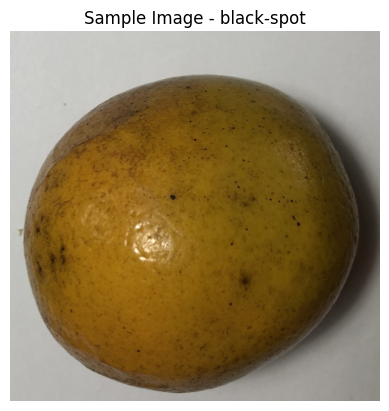

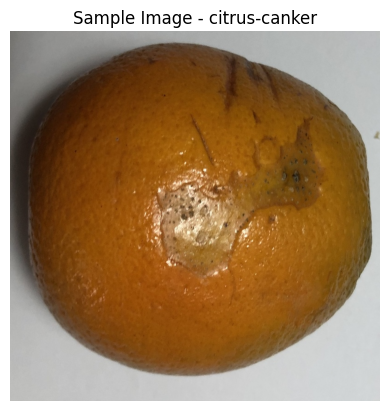

In [ ]:
def display_sample_images(data_dir, category):
    category_path = os.path.join(data_dir, category)
    image_files = os.listdir(category_path)

    if len(image_files) == 0:
        print(f"No images found in {category}!")
        return

    # Pick the first image from the category
    sample_image_path = os.path.join(category_path, image_files[0])

    # Read and display the image
    image = cv2.imread(sample_image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Sample Image - {category}")
    plt.show()

# Display a sample image from each category in Train folder
for category in categories:
    display_sample_images(train_dir, category)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create ImageDataGenerator for preprocessing and augmentation
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values (0 to 1)
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Load train dataset
train_generator = datagen.flow_from_directory(
    train_extract_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Load validation dataset
val_generator = datagen.flow_from_directory(
    train_extract_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Image Preprocessing Completed!")

Found 1626 images belonging to 1 classes.
Found 406 images belonging to 1 classes.
Image Preprocessing Completed!


In [ ]:
# Data Preprocessing and Augmentation
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

Found 2032 images belonging to 2 classes.
Found 407 images belonging to 2 classes.


In [ ]:
#Build the Model using MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False  # Freeze base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

#Compile and Train the Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

epochs = 10
history = model.fit(train_generator, epochs=epochs, validation_data=test_generator)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.6967 - loss: 0.5732 - val_accuracy: 0.8575 - val_loss: 0.3322
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9051 - loss: 0.2815 - val_accuracy: 0.9361 - val_loss: 0.2255
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.9371 - loss: 0.1944 - val_accuracy: 0.8968 - val_loss: 0.2428
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.9411 - loss: 0.1792 - val_accuracy: 0.9337 - val_loss: 0.1884
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9303 - loss: 0.1893 - val_accuracy: 0.9386 - val_loss: 0.1847
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9478 - loss: 0.1563 - val_accuracy: 0.9337 - val_loss: 0.1781
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.9486 - loss: 0.1473 - val_accuracy: 0.9484 - val_loss: 0.1480
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9514 - loss: 0.1343 - val_accuracy: 0.9533 - v

13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9531 - loss: 0.1372
Test Accuracy: 0.9533
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


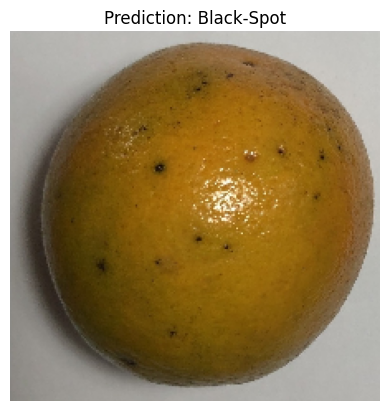

In [ ]:
# Evaluate the Model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

# Make Predictions on New Images
def predict_image(image_path):
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)[0][0]
    label = "Citrus-Canker" if prediction > 0.5 else "Black-Spot"

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {label}")
    plt.show()

#Test Prediction on a Sample Image
sample_image_path = os.path.join(test_dir, "black-spot", os.listdir(os.path.join(test_dir, "black-spot"))[0])
predict_image(sample_image_path)

Saving image-1.png to image-1.png
Image uploaded: image-1.png


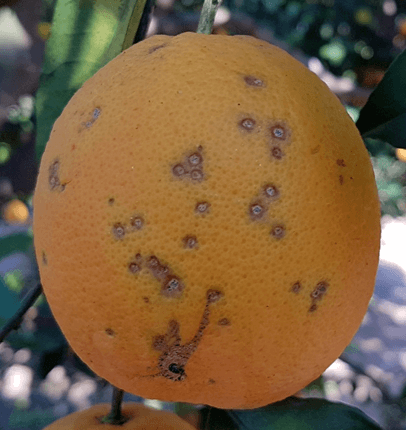

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


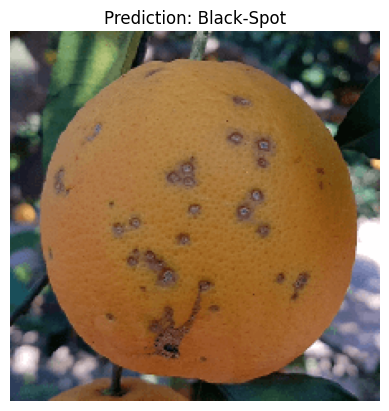

In [ ]:
from google.colab import files
from IPython.display import display
import PIL.Image

# Upload Image via Google Colab
def upload_and_predict():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img_path = filename
        print(f"Image uploaded: {img_path}")

        # Display the uploaded image
        display(PIL.Image.open(img_path))

        # Run prediction
        predict_image(img_path)

# Run this function to upload and classify any image
upload_and_predict()

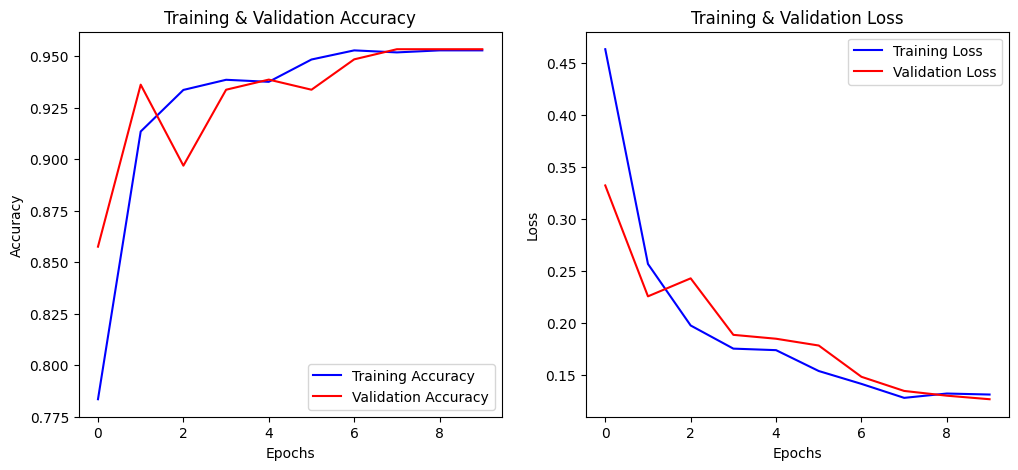

In [ ]:
import matplotlib.pyplot as plt

#Function to plot training history
def plot_training_history(history):
    # Extracting accuracy and loss values
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    #Plot Accuracy Graph
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy", color="blue")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy", color="red")
    plt.legend(loc="lower right")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")

    # Plot Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss", color="blue")
    plt.plot(epochs_range, val_loss, label="Validation Loss", color="red")
    plt.legend(loc="upper right")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")

    plt.show()

#Call this function after training the model
plot_training_history(history)


In [ ]:
#Load the Test Data
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    "/content/test_dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Evaluate the Model on Test Data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Model Test Accuracy: {test_accuracy:.4f}")
print(f"Model Test Loss: {test_loss:.4f}")

# Get Predictions
import numpy as np
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int) # Adjust for binary

# Get True Labels
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

#Generate a Classification Report
from sklearn.metrics import classification_report

report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:\n", report)

Found 407 images belonging to 2 classes.
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9665 - loss: 0.0813
Model Test Accuracy: 0.9533
Model Test Loss: 0.1265
13/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step
Classification Report:
                precision    recall  f1-score   support

   black-spot       0.94      0.97      0.95       206
citrus-canker       0.97      0.94      0.95       201

     accuracy                           0.95       407
    macro avg       0.95      0.95      0.95       407
 weighted avg       0.95      0.95      0.95       407



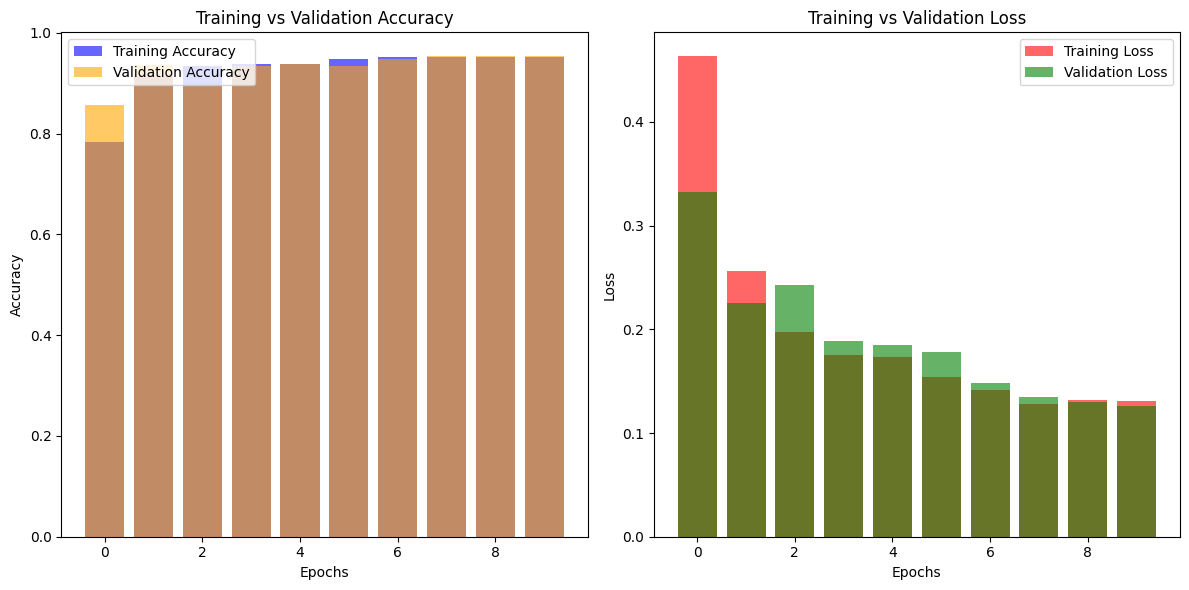

In [ ]:
import matplotlib.pyplot as plt

# Extract accuracy and loss values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(train_acc))

# Plot Accuracy Histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(epochs_range, train_acc, color='blue', alpha=0.6, label="Training Accuracy")
plt.bar(epochs_range, val_acc, color='orange', alpha=0.6, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Plot Loss Histogram
plt.subplot(1, 2, 2)
plt.bar(epochs_range, train_loss, color='red', alpha=0.6, label="Training Loss")
plt.bar(epochs_range, val_loss, color='green', alpha=0.6, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


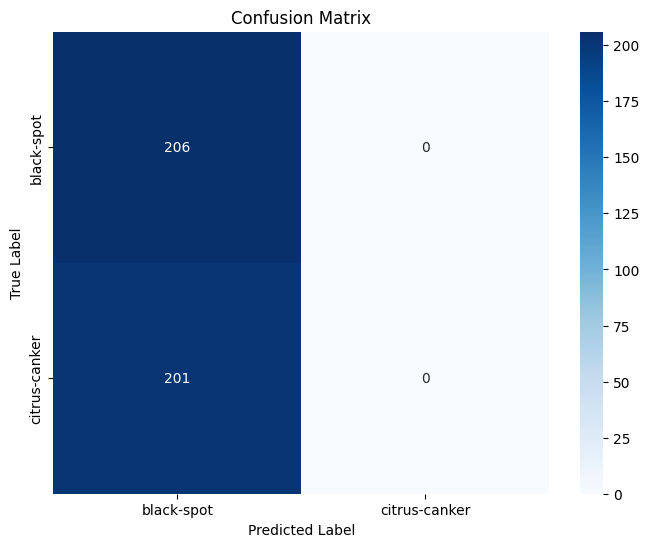

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate predictions
y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()



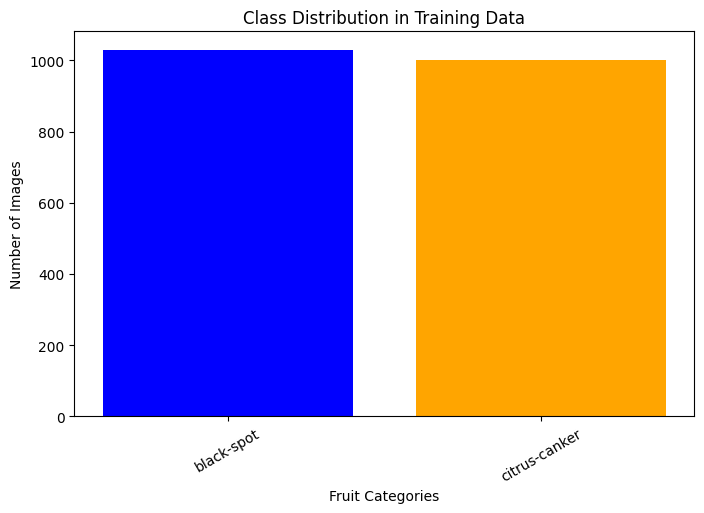

In [ ]:
import os
import numpy as np

# Count images in each category
train_categories = os.listdir(train_dir)
train_counts = [len(os.listdir(os.path.join(train_dir, cat))) for cat in train_categories]

# Bar plot
plt.figure(figsize=(8, 5))
plt.bar(train_categories, train_counts, color=['blue', 'orange', 'green', 'red'])
plt.xlabel("Fruit Categories")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Data")
plt.xticks(rotation=30)
plt.show()


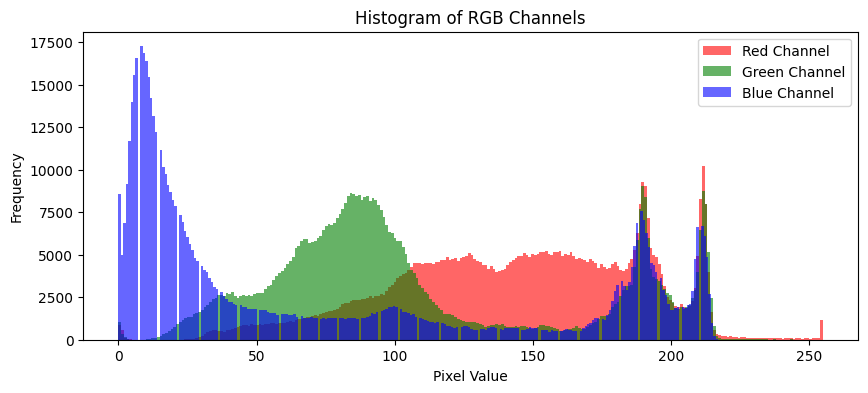

In [ ]:
from tensorflow.keras.models import Model

# Read an image
img_path = "/content/test_dataset/test/citrus-canker/citrus-canker (100).jpg"
img = cv2.imread(img_path)

# Convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Split channels
r, g, b = cv2.split(img_rgb)

# Plot histograms
plt.figure(figsize=(10, 4))
plt.hist(r.ravel(), bins=256, color='red', alpha=0.6, label="Red Channel")
plt.hist(g.ravel(), bins=256, color='green', alpha=0.6, label="Green Channel")
plt.hist(b.ravel(), bins=256, color='blue', alpha=0.6, label="Blue Channel")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Histogram of RGB Channels")
plt.legend()
plt.show()

